In [1]:
import pandas as pd


df = pd.read_csv('train.csv')

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

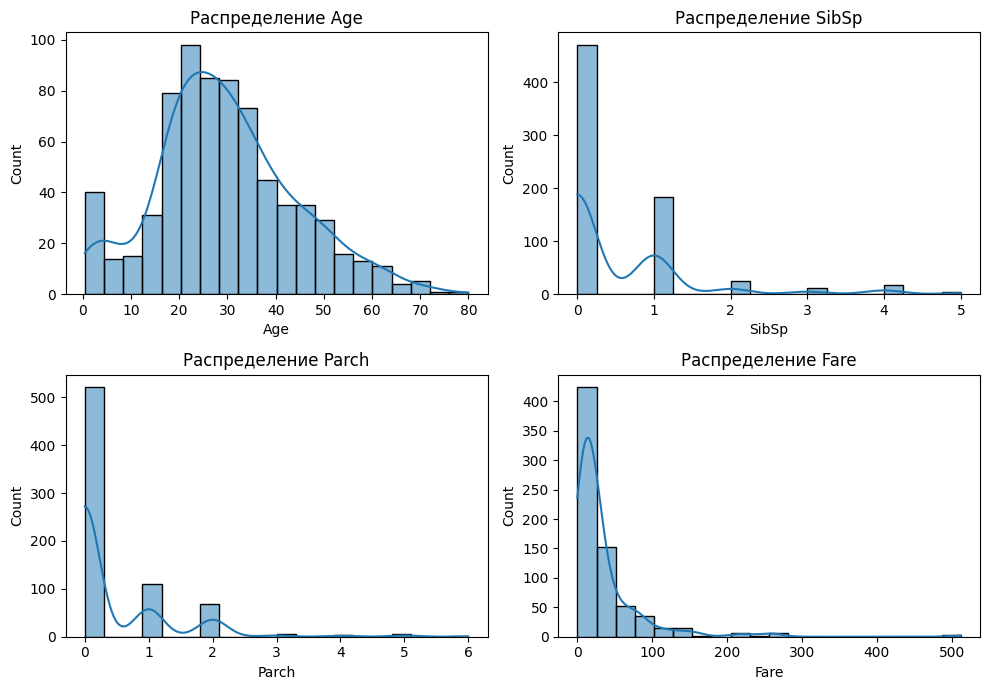

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


df_w_age = df.dropna(subset=['Age'])
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df_w_age[feature], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')

plt.tight_layout()
plt.show()

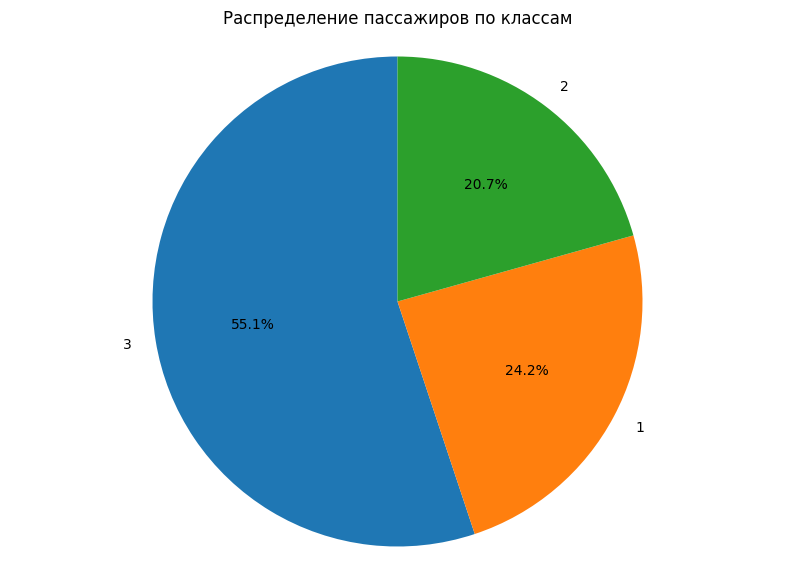

In [5]:
pclass_df = df['Pclass'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(pclass_df, labels=pclass_df.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение пассажиров по классам')
plt.axis('equal')
plt.show()

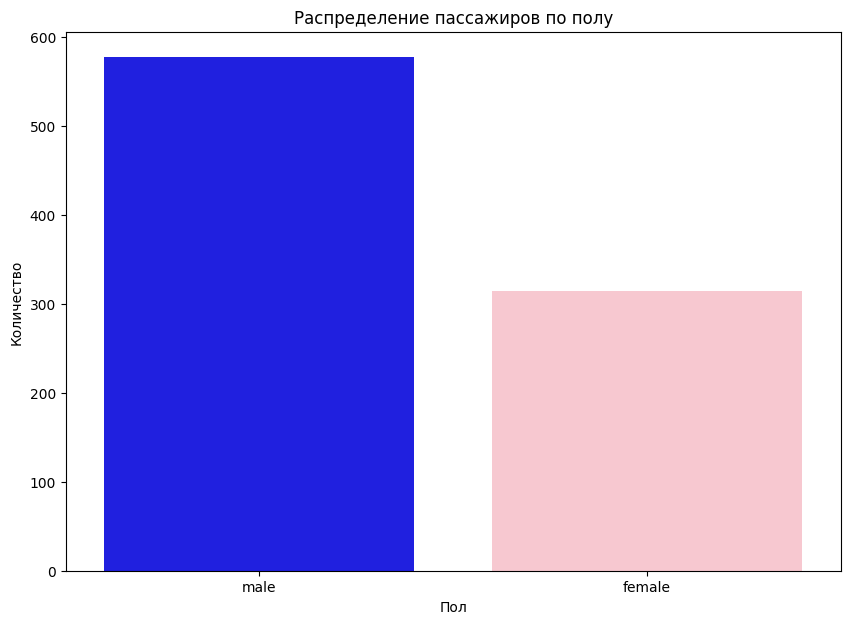

In [6]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Sex', hue='Sex', palette=['blue', 'pink'], legend=False)
plt.title('Распределение пассажиров по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

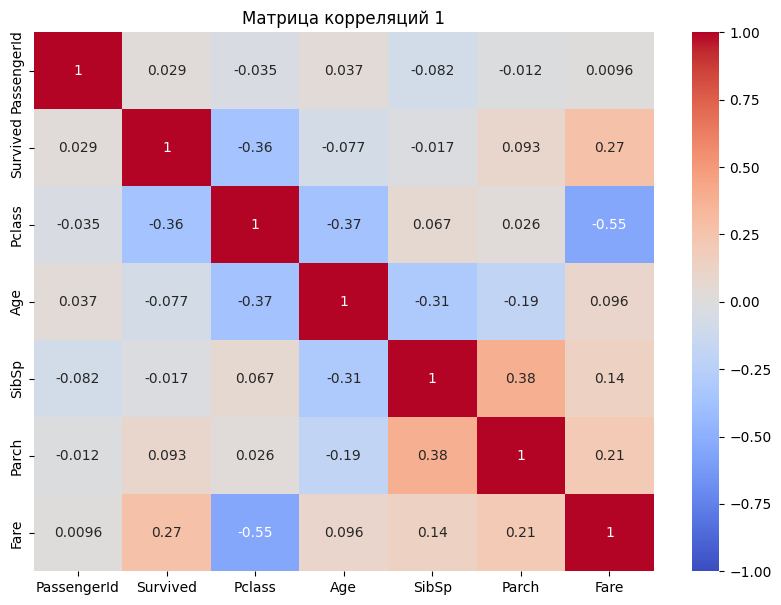

In [7]:
corr = df_w_age.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций 1')
plt.show()

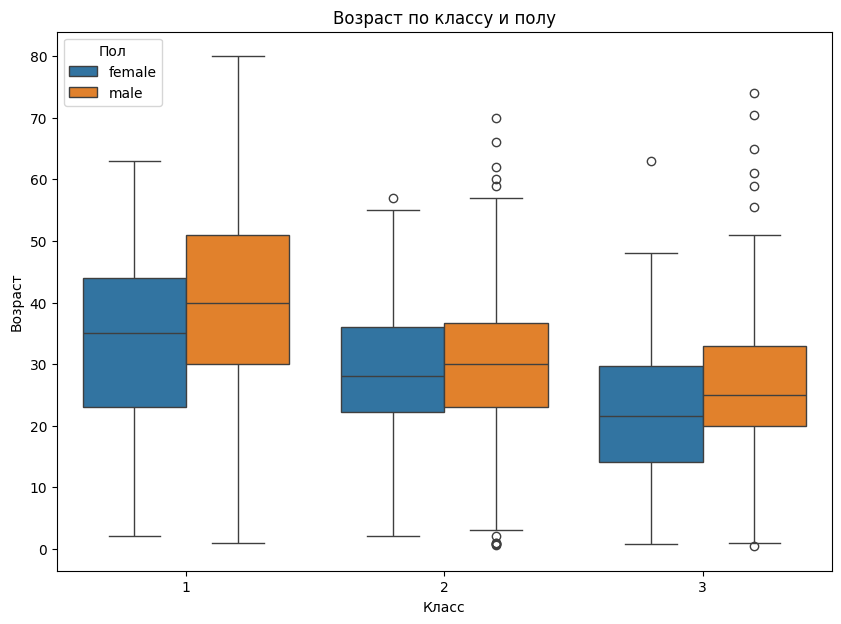

In [8]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df_w_age)

plt.title('Возраст по классу и полу')
plt.xlabel('Класс')
plt.ylabel('Возраст')
plt.legend(title='Пол')
plt.show()

In [9]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [10]:
unique_cabins = df['Cabin'].dropna().to_numpy()

print(unique_cabins)

['C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33' 'B30'
 'C52' 'B28' 'C83' 'F33' 'F G73' 'C23 C25 C27' 'E31' 'A5' 'D10 D12' 'D26'
 'C110' 'B58 B60' 'E101' 'D26' 'F E69' 'D47' 'C123' 'B86' 'F2' 'C2' 'E33'
 'B19' 'A7' 'C49' 'F4' 'A32' 'F2' 'B4' 'B80' 'G6' 'A31' 'D36' 'D15' 'C93'
 'C83' 'C78' 'D35' 'G6' 'C87' 'B77' 'E67' 'B94' 'C125' 'C99' 'C118' 'D7'
 'A19' 'B49' 'D' 'C22 C26' 'C106' 'B58 B60' 'E101' 'C22 C26' 'C65' 'E36'
 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'D' 'B18' 'C124' 'C91' 'C2'
 'E40' 'T' 'F2' 'C23 C25 C27' 'F33' 'C128' 'E33' 'D37' 'B35' 'E50' 'C82'
 'B96 B98' 'D36' 'G6' 'C78' 'E10' 'C52' 'E44' 'B96 B98' 'C23 C25 C27'
 'A34' 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'D' 'A14' 'B49' 'C93'
 'B37' 'C30' 'D20' 'C22 C26' 'B79' 'C65' 'E25' 'D46' 'F33' 'B73' 'B18'
 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'E67' 'C101' 'E25' 'E44' 'C68'
 'A10' 'E68' 'B41' 'D20' 'A20' 'C125' 'F4' 'D19' 'D50' 'D9' 'A23' 'B50'
 'B35' 'D33' 'A26' 'D48' 'E58' 'C126' 'B71' 'B51 B53 B

In [11]:
df['Deck'] = df['Cabin'].str.extract(r'^([A-Za-z])', expand=False).fillna('M')

In [12]:
df[['Cabin', 'Deck']]

,Cabin,Deck
0,NaN,M
1,C85,C
2,NaN,M
3,C123,C
4,NaN,M
...,...,...
886,NaN,M
887,B42,B
888,NaN,M
889,C148,C


In [13]:
df['Cab_count'] = df['Cabin'].str.count(r'[A-Z]\d+').fillna(0).astype(int)

In [14]:
df[df['Cabin'].notna()][['Cabin', 'Cab_count']].head(10)

,Cabin,Cab_count
1,C85,1
3,C123,1
6,E46,1
10,G6,1
11,C103,1
21,D56,1
23,A6,1
27,C23 C25 C27,3
31,B78,1
52,D33,1


In [15]:
df.drop(['Cabin'], axis=1, inplace=True)

In [16]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Cab_count
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN,B,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN,B,1


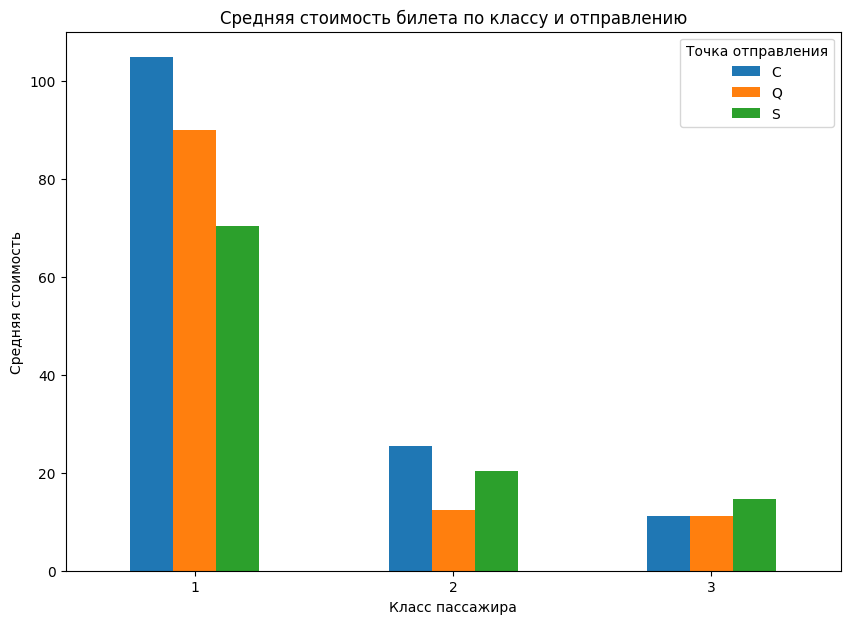

In [17]:
df_w_emb = df.dropna(subset=['Embarked'])

df_fare = df_w_emb.groupby(['Pclass', 'Embarked'])['Fare'].mean().unstack()

df_fare.plot(kind='bar', figsize=(10, 7))
plt.title('Средняя стоимость билета по классу и отправлению')
plt.ylabel('Средняя стоимость')
plt.xlabel('Класс пассажира')
plt.legend(title='Точка отправления')
plt.xticks(rotation=0)
plt.show()

In [18]:
df['Fare_round'] = df['Fare'].round(-1)

In [19]:
fare_class_mode = df.groupby(['Pclass', 'Fare_round'])['Embarked'].transform(
    lambda x: x.mode()[0]
)

In [20]:
df['Embarked'] = df['Embarked'].fillna(fare_class_mode)

In [21]:
df.loc[df['PassengerId'].isin([62, 830])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Cab_count,Fare_round
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,C,B,1,80.0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,C,B,1,80.0


In [22]:
df.drop(['Fare_round'], axis=1, inplace=True)

In [23]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
Cab_count      0
dtype: int64

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Cab_count
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,M,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,M,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,M,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,M,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,B,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S,M,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,C,1


In [25]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [26]:
from sklearn.preprocessing import LabelEncoder


lab_enc = LabelEncoder()
df['Sex'] = lab_enc.fit_transform(df['Sex'])

In [27]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [28]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb', drop_first=True, dtype=int)

In [29]:
df['Deck'].unique()

<StringArray>
['M', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

In [30]:
from sklearn.model_selection import KFold
import numpy as np


kf = KFold(n_splits=5, shuffle=True, random_state=42)

df['Deck_tar_enc'] = np.nan

for train_idx, val_idx in kf.split(df):
    train_fold = df.iloc[train_idx]
    deck_means = train_fold.groupby('Deck')['Survived'].mean()
    df.loc[val_idx, 'Deck_tar_enc'] = df.iloc[val_idx]['Deck'].map(deck_means)

global_mean = df['Survived'].mean()
df['Deck_tar_enc'] = df['Deck_tar_enc'].fillna(global_mean).round(3)

In [31]:
df.drop('Deck', axis=1, inplace=True)

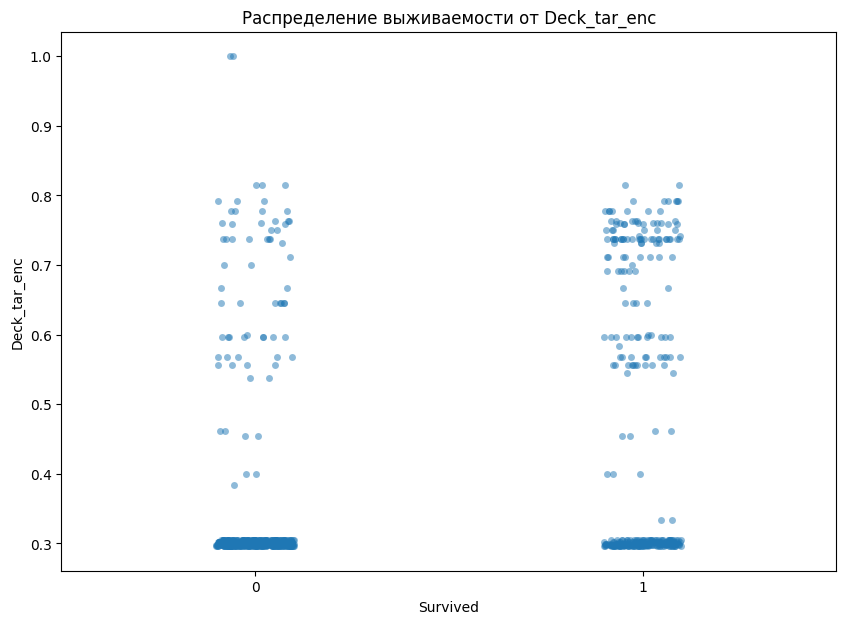

In [32]:
plt.figure(figsize=(10, 7))
sns.stripplot(x='Survived', y='Deck_tar_enc', data=df, jitter=True, alpha=0.5)
plt.title('Распределение выживаемости от Deck_tar_enc')
plt.xlabel('Survived')
plt.ylabel('Deck_tar_enc')
plt.show()

In [33]:
df['Designation'] = df.Name.str.extract(' ([A-Za-z]+)\.')

In [34]:
df['Designation'].isnull().sum()

np.int64(0)

In [35]:
df['Designation'].value_counts()

Designation
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [36]:
df['Designation'] = df['Designation'].replace(
    df['Designation'].value_counts()[df['Designation'].value_counts() < 40].index, 
    'Uniq'
)

In [37]:
df['Designation'].unique()

<StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Uniq']
Length: 5, dtype: str

In [38]:
designations= {
    'Mr': 0,
    'Mrs': 1,
    'Miss': 2,
    'Master': 3,
    'Uniq': 4,
}

df['Designation'] = df['Designation'].map(designations)

In [39]:
df.drop('Name', axis=1, inplace=True)

In [40]:
df['Family'] = df['SibSp'] + df['Parch']

In [41]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [42]:
df['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [43]:
df['Ticket_uniq'] = df['Ticket'].map(df['Ticket'].value_counts()).apply(
    lambda x: 1 if x == 1 else 0
)

In [44]:
df.drop('Ticket', axis=1, inplace=True)

In [45]:
df = df.drop('PassengerId', axis=1)

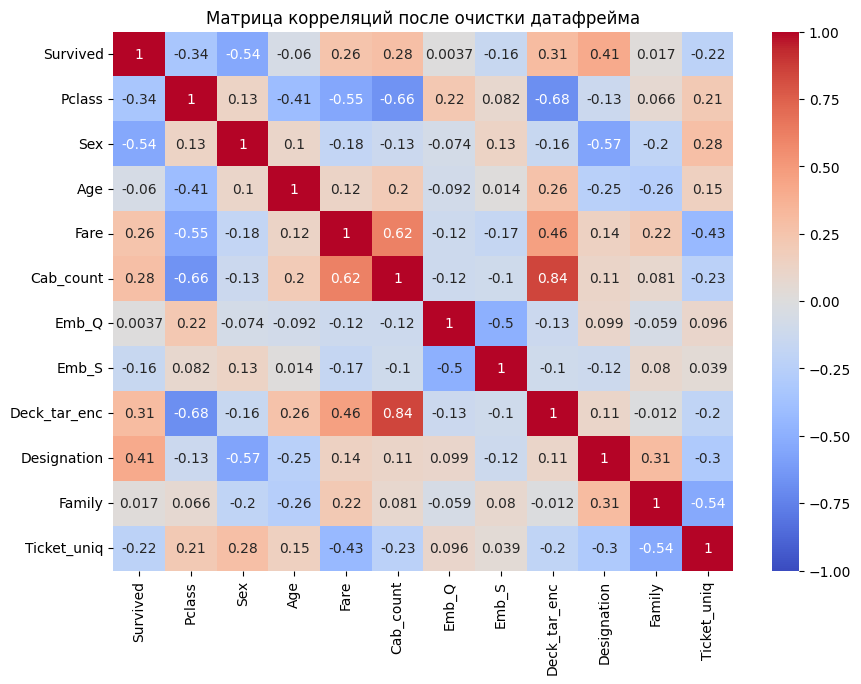

In [46]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций после очистки датафрейма')
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline


X = df.drop('Survived', axis=1)
y = df['Survived']

pipe_tsne = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('tsne', TSNE(
            n_components=2,
            random_state=42,
            perplexity=30,
            learning_rate='auto',
            max_iter=1000,
            init='pca'
        ))
    ]
)

X_tsne = pipe_tsne.fit_transform(X)

In [48]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=[
        'tsne_1',
        'tsne_2'
    ]
)

tsne_df['target'] = y

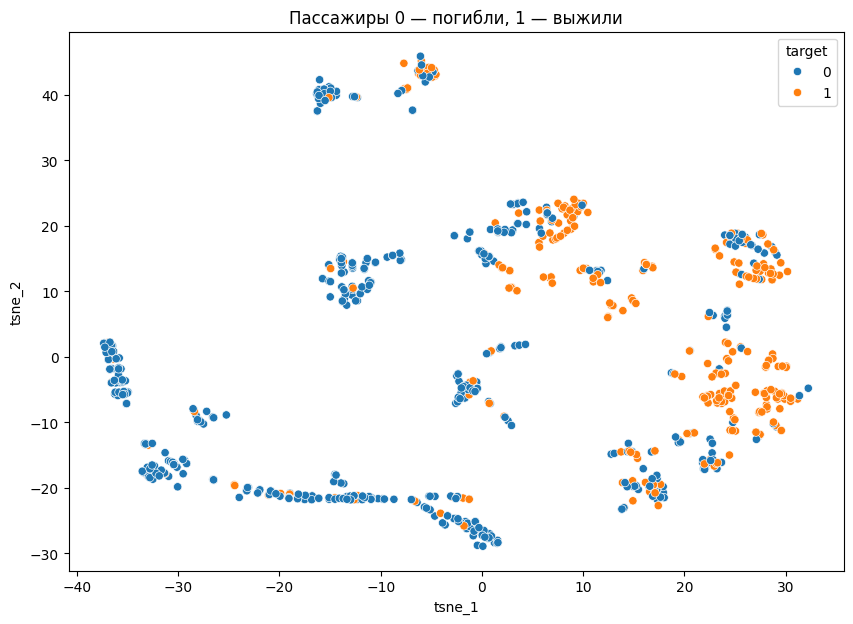

In [49]:
fig = plt.figure(figsize=(10, 7))
    
sns.scatterplot(
    data=tsne_df,
    x='tsne_1', 
    y='tsne_2',
    hue='target',
)
plt.title('Пассажиры 0 — погибли, 1 — выжили')
plt.show()

In [50]:
df.to_csv('train_prep.csv', index=False)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Pclass        891 non-null    int64  
 2   Sex           891 non-null    int64  
 3   Age           891 non-null    float64
 4   Fare          891 non-null    float64
 5   Cab_count     891 non-null    int64  
 6   Emb_Q         891 non-null    int64  
 7   Emb_S         891 non-null    int64  
 8   Deck_tar_enc  891 non-null    float64
 9   Designation   891 non-null    int64  
 10  Family        891 non-null    int64  
 11  Ticket_uniq   891 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 83.7 KB
